# 📈 Simple Linear Regression: From Intuition to Implementation

**Simple Linear Regression** is a statistical method used to model and analyze the relationship between two continuous variables.

Its primary goal is to find the "line of best fit" that mathematically describes how changes in one variable cause proportional changes in the other. It is called "simple" because it only uses one predictor variable.

### **The Core Components**

In simple linear regression, the two variables are:

1. **The Independent Variable ($x$):** The predictor or explanatory variable (e.g., Years of Experience).
2. **The Dependent Variable ($y$):** The target or outcome you are trying to predict (e.g., Salary).

### **The Mathematical Equation**

The relationship is expressed through the classic equation of a straight line:

$y = \beta_0 + \beta_1x + \epsilon$

* **$y$:** The predicted value of the dependent variable.
* **$x$:** The actual value of the independent variable.
* **$\beta_0$ (Intercept):** The theoretical value of $y$ when $x$ is exactly $0$.
* **$\beta_1$ (Slope/Coefficient):** The core of the model. It represents exactly how much $y$ changes for every one-unit increase in $x$.
* **$\epsilon$ (Error Term):** The "residual" or noise. Real-world data rarely falls perfectly on a straight line, so this term accounts for the natural variance or prediction error.

### **How it Works (Ordinary Least Squares)**

To find the perfect line, the algorithm typically uses a method called **Ordinary Least Squares (OLS)**.

Imagine a scatter plot of your data points. The OLS algorithm draws a line through the points, measures the vertical distance from every single dot to that line (the error), squares those distances, and adds them all up. It adjusts the line repeatedly until it finds the exact slope ($\beta_1$) and intercept ($\beta_0$) that result in the smallest possible sum of those squared errors.



## 🥔 1. Intuition: The Potato Farm Example

Imagine a farmer who wants to predict the **potato yield** ($y$) based on the **amount of nitrogen fertilizer** used ($x$).

The Simple Linear Regression equation is:
$$y = b_0 + b_1 x$$

| Symbol | Name | Meaning in our Example |
| :---: | :--- | :--- |
| **$y$** | Dependent Variable | Potato yield in tons (What we predict) |
| **$x$** | Independent Variable | Nitrogen fertilizer in kg (The predictor) |
| **$b_0$** | Y-Intercept | Base yield if 0 fertilizer is used |
| **$b_1$** | Slope | How much yield increases for every 1kg of fertilizer |

**Example:** If the algorithm finds $b_0 = 8$ and $b_1 = 3$, the equation is $y = 8 + 3x$. 
*Meaning: Even with 0 fertilizer, you get 8 tons. For every 1kg added, you get 3 more tons!*

## 📏 2. Ordinary Least Squares (OLS)

How do we find the "best" line out of infinite possibilities? We use **OLS**, which minimizes the sum of squared residuals.

### 📊 Diagram: Residuals and the Best Fit Line
```text
  Yield (y)
    ^
    |           * (Actual y_i)
    |          /|
    |         / |  <- Residual (Error)
    |        /  |     (y_i - y_hat_i)
    |-------*---|-----> Best Fit Line (y_hat = b_0 + b_1*x)
    |      /    |
    |     /     |
    |____/______|________> Fertilizer (x)
```

**The Goal of OLS:**
1. Calculate the **residual** (difference between actual $y_i$ and predicted $\hat{y}_i$) for every data point.
2. **Square** each residual (to remove negative signs and penalize larger errors).
3. **Sum** them all up.
4. The "Best Line" is the one that **minimizes this sum of squared residuals**.

---    
### What is Ordinary Least Squares (OLS)?

When you plot data points on a scatter plot, there are infinitely many straight lines you could draw through them. OLS is the mathematical algorithm used by Simple Linear Regression to officially decide which of those infinite lines is the **"Line of Best Fit."**

It does this by focusing on the **residuals** (the errors). A residual is the vertical distance between a real data point and the regression line. OLS calculates the size of every single residual, squares them, adds them all together, and finds the specific line that makes this final total as small as possible.


### The OLS Formula Breakdown

**1. The Equation of the Line**
Our goal is to find a line represented by the classic equation:


$$\hat{y}_i = b_0 + b_1x_i$$

* **$\hat{y}_i$ (Y-hat):** The *predicted* value that sits perfectly on the line.
* **$b_0$:** The y-intercept.
* **$b_1$:** The slope.

**2. The Residual (The Error)**
For every data point, the model makes a mistake. The residual ($e_i$) is the difference between the **Actual Value ($y_i$)** and the **Predicted Value ($\hat{y}_i$)**:


$$e_i = y_i - \hat{y}_i$$

**3. The OLS Objective Function**
We want to minimize the total error. However, we cannot just add up the raw residuals, because some are positive (point is above the line) and some are negative (point is below the line). If we added them, a +5 error and a -5 error would cancel out to 0, falsely making the model look perfect.

To fix this, OLS squares every residual before summing them up. The formula for the **Sum of Squared Residuals (SSR)** is:


$$SSR = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

By substituting our line equation into the SSR formula, we get the final OLS equation:


$$\text{Minimize} \sum_{i=1}^{n} (y_i - (b_0 + b_1x_i))^2$$

The algorithm uses calculus (taking the derivative and setting it to zero) to instantly find the exact $b_0$ and $b_1$ values that minimize that equation.

### Why do we *Square* the residuals?

1. **Removes negative signs:** Squaring ensures all errors are positive numbers.
2. **Penalizes large outliers:** An error of $2$ becomes $4$, but an error of $10$ becomes $100$. OLS aggressively punishes lines that are very far away from even a single data point.
3. **Calculus-friendly:** The squared function is a smooth, continuous curve (a parabola), which makes it mathematically easy for computers to find the exact bottom (minimum).

---

### 🤯 Fun Facts
1. **The Origins:** OLS was independently discovered by Legendre (1805) and Gauss (1809). Gauss used it to predict the orbit of the dwarf planet **Ceres**! 🪐
2. **Why "Ordinary"?** It's called "ordinary" because it treats all data points equally (unlike Weighted Least Squares).
3. **Why Square the errors?** 
   - Removes negative signs (so errors don't cancel out).
   - **Penalizes outliers** heavily (a large error becomes a massive number when squared).
   - Mathematically convenient for calculus optimization.


## 🛠️ Step 1: Data Preprocessing

We are using a dataset with **30 observations** and **2 columns**:
* **Feature ($X$)**: Years of Experience
* **Target ($y$)**: Salary


In [9]:
# numpy is the foundational library for numerical computing in Python. 
# We import it as 'np' (the industry-standard alias) to handle complex mathematical operations and multi-dimensional arrays efficiently.
import numpy as np

# matplotlib.pyplot is the classic 2D plotting library used to create charts, graphs, and visual plots.
# We import it as 'plt' so we can easily call its visualization functions later to view our regression line and actual data points.
import matplotlib.pyplot as plt

# pandas is the absolute standard for data manipulation and analysis. 
# We import it as 'pd' to easily load, clean, and explore structured, tabular data (like CSVs, Excel files, or SQL tables).
import pandas as pd

# os is a built-in Python module used for interacting with the operating system.
# It is highly useful for navigating directories, checking if files exist, and managing file paths dynamically so your code doesn't break if you move folders around.
import os

# pd.read_csv() is the pandas function that reads a Comma-Separated Values file and converts it into a structured, 2D table called a DataFrame.
# The 'r' placed immediately before the quote stands for "raw string". It forces Python to treat the backslashes (\) in your file path as literal characters instead of escape characters (like \n for a new line). This is a crucial trick for making Windows file paths work correctly!
salary_data = pd.read_csv(r'D:\Projects\personalNotes\assets\2_regression\1_simpleLinearRegression\Salary_Data.csv')

# .head() is a quick inspection method. By default, it returns the top 5 rows of your newly loaded DataFrame.
# You use this immediately after loading a dataset to visually verify that the column headers aligned properly and the data actually imported exactly as you expected.
salary_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [26]:
# .describe() is an incredibly powerful pandas method that generates descriptive statistics for all numerical columns in your DataFrame.
# It automatically calculates and displays the count, mean (average), standard deviation, minimum value, maximum value, and the 25th, 50th (median), and 75th percentiles.
# Data scientists use this immediately after loading data to spot anomalies, understand the spread of the data, and check for extreme outliers.

print(salary_data.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [ ]:
# .info() provides a concise, technical summary of your DataFrame's structure and metadata.
# It tells you the total number of rows and columns, the name of each column, the exact count of non-null (non-missing) values in each column, and the data type of each column (e.g., float64 for decimals, int64 for integers, object for text).
# This is your first line of defense to check if your data types loaded correctly and to quickly spot if you have any missing data (null values) that need to be handled during preprocessing.

print(salary_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


In [27]:
# X represents the independent variables (features) we use to make predictions.
# .iloc stands for "integer location" and is used to select rows and columns by their numerical index.
# [:, :-1] is split into two parts by the comma:
#    1st part ':' means "give me ALL the rows".
#    2nd part ':-1' means "give me all the columns EXCEPT the very last one".
# .values extracts just the raw data as a NumPy array (stripping away the pandas row/column labels), which is required by machine learning libraries.

X = salary_data.iloc[:, :-1].values 

# y represents the dependent variable (the target/label we are trying to predict).
# [:, -1] is also split into two parts:
#    1st part ':' means "give me ALL the rows".
#    2nd part '-1' means "give me ONLY the very last column".
# .values again converts this into a NumPy array.

y = salary_data.iloc[:, -1].values

print(f"✅ Data loaded! X shape: {X.shape}, y shape: {y.shape}")

✅ Data loaded! X shape: (30, 1), y shape: (30,)


In [28]:
# from sklearn.model_selection import train_test_split imports a utility function used to partition data into random splits.
# This prevents overfitting by separating the data we use to teach the model from the data we use to evaluate its real-world performance.

from sklearn.model_selection import train_test_split

# train_test_split shuffles and splits the feature matrix (X) and target vector (y) into four separate arrays simultaneously.
# The precise unpacking order (X_train, X_test, y_train, y_test) must be strictly maintained.
# test_size = 0.2 allocates exactly 20% of the entire dataset to the test partition, leaving the remaining 80% for training.
# random_state = 0 fixes the random number generator's seed, making sure the random split is completely identical and reproducible every time you execute this cell.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# print(f"...") uses an f-string (formatted string literal), which allows Python expressions to be evaluated directly inside curly braces {}.
# .shape is a native NumPy array attribute that returns a tuple showing the exact dimensions (number of rows, number of columns) of the target array.
# Data engineers use this check immediately after a split to verify that data rows match expectations before moving to model training.

print(f"✅ Data loaded! X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

✅ Data loaded! X_train shape: (24, 1), y_train shape: (24,)


## 🧠 Step 2: Training the Simple Linear Regression Model

We use the `scikit-learn` library. 
1. We import the `LinearRegression` class.
2. We create an **object** (instance) of this class called `regressor`.
3. We train the model using the **`.fit()`** method, passing in `X_train` and `y_train`.

> 💡 **ML Engineer Insight:** The `.fit()` method is universal in scikit-learn. Whether you use Random Forests, XGBoost, or Neural Networks later, you will *always* use `model.fit(X, y)` to train!

In [37]:
# from sklearn.linear_model import LinearRegression imports the primary class used to perform ordinary least squares linear regression.
# This algorithm minimizes the residual sum of squares between the observed targets in the dataset and the targets predicted by the linear approximation.

from sklearn.linear_model import LinearRegression

# LinearRegression() initializes a new instance of the regression algorithm using its default hyperparameters (such as fit_intercept=True).
# By assigning it to the variable 'regressor', we create a dedicated object in memory that will retain its learned mathematical state after the training process is complete.

regressor = LinearRegression()

# The .fit() method executes the core mathematical optimization, actively teaching the model the relationship between the input features (X_train) and the target variable (y_train).
# Under the hood, this step calculates the optimal line of best fit by determining the exact intercept and slope coefficients that result in the lowest possible overall error.

regressor.fit(X_train, y_train)

# print() outputs a standard confirmation string to the console, reassuring the developer that the optimization phase completed without throwing any runtime exceptions.

print("🎉 Model trained successfully!")

# regressor.intercept_ is an internal attribute generated only after fitting (denoted by scikit-learn's trailing underscore convention) representing the expected value of y when all X features are exactly 0.
# The format specifier :,.2f inside the f-string automatically formats the raw float to include thousands comma separators (,) and rounds to exactly two decimal places (.2f) for standard currency representation.

print(f"📌 Intercept (b0): ${regressor.intercept_:,.2f}")

# regressor.coef_ returns a NumPy array containing the estimated mathematical weights (slopes) for the regression equation, providing one coefficient for every feature present in X_train.
# We slice index [0] to extract the specific numeric weight for our single input feature, which explicitly defines how much the target variable will increase or decrease for every single unit change in experience.

print(f"📌 Slope (b1): ${regressor.coef_[0]:,.2f} per year of experience")
print(f"📌 Regression Equation: Salary = ${regressor.intercept_:,.2f} + (${regressor.coef_[0]:,.2f} * YearsExperience)")

🎉 Model trained successfully!
📌 Intercept (b0): $26,780.10
📌 Slope (b1): $9,312.58 per year of experience
📌 Regression Equation: Salary = $26,780.10 + ($9,312.58 * YearsExperience)


## 🔮 Step 3: Predicting & Evaluating

Now that the model is trained, we want to see how well it predicts salaries for employees it has never seen before (the Test Set).

We use the **`.predict()`** method and pass in `X_test` (the years of experience for the test set).

* **MAE** (Mean Absolute Error): Average absolute difference.
* **RMSE** (Root Mean Squared Error): Penalizes large errors.
* **R² Score**: How much of the variance in $Y$ is explained by $X$ (1.0 is perfect).

In [38]:
# from sklearn.metrics imports specific mathematical functions to quantify how accurately our trained model generalizes to unseen data.
# These metrics evaluate performance by comparing the model's generated predictions against the actual ground-truth values in our test set.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Predict Test set results
# The .predict() method feeds the previously isolated test features (X_test) through the regression equation we learned during training.
# It returns a 1D NumPy array of predicted target values (y_pred), which we can now benchmark against the true test values (y_test).

y_pred = regressor.predict(X_test)

# 2. Calculate Evaluation Metrics
# Mean Absolute Error (MAE) calculates the average absolute distance between the predicted target and the actual target.
# It provides a highly interpretable baseline error metric in the exact same units as our target variable (dollars), treating all errors proportionally.

mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error (RMSE) first squares the errors before averaging them, which heavily penalizes large outliers or massive prediction misses.
# Taking the square root via np.sqrt() brings the final penalty metric back down to our original currency scale for practical interpretation.

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# The R² (Coefficient of Determination) score measures goodness-of-fit, scaling up to a maximum perfect score of 1.0.
# It mathematically represents the exact proportion of the total variation in the target variable that is successfully explained by our input features.

r2 = r2_score(y_test, y_pred)

# Python's string multiplication cleanly duplicates the equals sign 40 times to create an immediate visual boundary in the console logs.

print("="*40)
print("📊 MODEL EVALUATION METRICS")
print("="*40)

# Standard f-strings dynamically inject our calculated metrics into the print statements at runtime.
# The :,.2f format specifier converts the raw floating-point error into standard readable currency with thousands separators and two decimal places.

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")

# We format the raw R² score to four decimal places (.4f) for precision, and also multiply by 100 inline to present a readable percentage score.

print(f"R²   : {r2:.4f} ({r2*100:.2f}% of variance explained)")

# 3. Make a Single New Prediction
# Scikit-learn's .predict() method strictly requires a 2D array matrix of shape [n_samples, n_features] to maintain consistent dimensions.
# We use double brackets [[ ]] inside np.array() to simulate a matrix containing exactly one sample row consisting of one feature column (7.5 years).

new_experience = np.array([[7.5]]) # 7.5 years

# The model processes this new 2D data point through the established intercept and slope coefficients to output a brand new array of predictions.

pred_salary = regressor.predict(new_experience)

# Because pred_salary returns as an array, we slice index [0] to extract the isolated scalar floating-point value, rendering it natively in our UI output.

print(f"\n🎯 Prediction for 7.5 years experience: ${pred_salary[0]:,.2f}")

📊 MODEL EVALUATION METRICS
MAE  : $2,446.17
RMSE : $3,580.98
R²   : 0.9882 (98.82% of variance explained)

🎯 Prediction for 7.5 years experience: $96,624.41


## 📈 Step 4: Visualizing the Results

We will use `matplotlib` to plot:
1. **Red dots**: The actual/real salaries (`plt.scatter`).
2. **Blue line**: The predicted salaries / regression line (`plt.plot`).

### ⚠️ The "Test Set Plot" Trick
When plotting the **Test Set**, do we change the regression line code from `X_train` to `X_test`? 
**NO!** Because Simple Linear Regression results in a *single unique equation*, the regression line is exactly the same whether you plot it against the training or test X-coordinates. We only change the scatter plot dots to `X_test` and `y_test`.

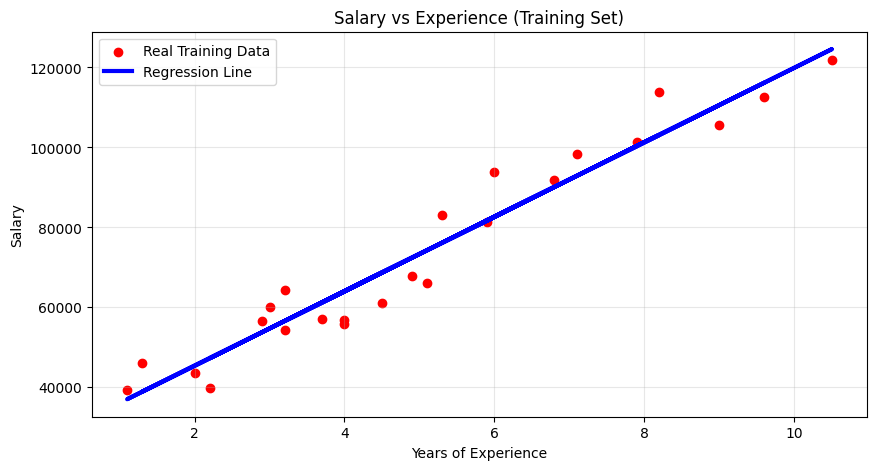

In [39]:
# Data visualization is a critical step to visually verify that our model's mathematical line of best fit accurately represents the actual underlying data trend.
# We start by initializing a new blank canvas using plt.figure(), passing a tuple (10, 5) to figsize to dictate the width and height in inches for optimal readability.

plt.figure(figsize=(10, 5))

# plt.scatter() plots each individual observation from our training data as a distinct dot on the graph without connecting them.
# We map Experience (X_train) to the x-axis and actual Salary (y_train) to the y-axis, coloring them red to clearly distinguish real-world ground truth data.

plt.scatter(X_train, y_train, color = 'red', label='Real Training Data')

# plt.plot() draws a continuous 2D line connecting a sequence of coordinates.
# By plotting the original inputs (X_train) against the model's exact predictions for those inputs (regressor.predict(X_train)), we vividly generate the linear line of best fit.
# We make it blue and increase the linewidth to 3 so the model's learned equation visually stands out against the scattered data points.

plt.plot(X_train, regressor.predict(X_train), color = 'blue', linewidth=3, label='Regression Line')

# plt.title(), plt.xlabel(), and plt.ylabel() append essential string metadata to the chart.
# This ensures that any stakeholders or non-technical reviewers instantly understand the specific units and context being visualized without needing to read the code.

plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

# plt.legend() reads the 'label' arguments we defined in the scatter and plot functions above, rendering a key in the corner to help viewers identify what each color represents.

plt.legend()

# plt.grid() activates background gridlines, making it significantly easier to visually estimate the exact x and y coordinates of specific points on the chart.
# We set alpha=0.3 to make the grid highly transparent (30% opacity) so it provides structure without visually overpowering the actual regression data.

plt.grid(True, alpha=0.3)

# plt.show() is the final execution command that tells Matplotlib's backend engine to compile all the layered graphical elements and push the completed visual to your display.

plt.show()

## 🎤 Top Interview Questions

### 🟢 Basic Level
**Q1: What is the difference between Regression and Classification?**
> **A:** Regression predicts continuous numerical values (e.g., Salary, Temperature). Classification predicts discrete categories/classes (e.g., Spam/Not Spam, Cat/Dog).

**Q2: What do $b_0$ and $b_1$ represent?**
> **A:** $b_0$ is the Y-intercept (value of Y when X=0). $b_1$ is the slope (change in Y for a 1-unit increase in X).

### 🟡 Intermediate Level
**Q3: What is the conceptual difference between `.fit()` and `.predict()`?**
> **A:** `.fit()` is for **training** (it calculates the internal weights/intercept). `.predict()` is for **inference** (it uses those learned weights to output predictions for new data).

**Q4: Why do we square the residuals in OLS instead of taking the absolute value?**
> **A:** 1) It removes negative signs. 2) It heavily penalizes outliers. 3) It is mathematically differentiable everywhere, making calculus optimization possible.

### 🔴 Advanced Level
**Q5: Why do we use `X_train` to plot the regression line on the Test Set graph?**
> **A:** Because the model learned a *single mathematical equation* from the training data. The line is identical regardless of whether you pass `X_train` or `X_test` to the predict function. Using `X_train` just ensures the line spans the full width of the graph.

**Q6: What are the core assumptions of Linear Regression?**
> **A:** 1) Linearity (relationship between X and Y is linear). 2) Independence (observations are independent). 3) Homoscedasticity (constant variance of residuals). 4) Normality (residuals are normally distributed).

**Q7: Why do we square the residuals in OLS instead of just taking the absolute value (Mean Absolute Error)?**
> **Answer:** 
> 1. **Penalty for outliers:** Squaring penalizes larger errors much more heavily than absolute values, forcing the line to stay closer to extreme outliers.
> 2. **Mathematical convenience:** The squared function is strictly differentiable everywhere, making it easy to find the exact minimum using calculus (taking the derivative and setting it to zero). Absolute value has a "sharp corner" at zero, making calculus harder.
> 3. **Gaussian Assumption:** If we assume the errors are normally distributed (Gaussian noise), maximizing the likelihood is mathematically equivalent to minimizing the squared errors.

**Q8: In scikit-learn, what is the conceptual difference between the `.fit()` and `.predict()` methods?**
> **Answer:** 
> * **`.fit()`** is used for **training**. It looks at the data (`X_train`, `y_train`) and calculates the internal parameters (weights/coefficients and bias/intercept). It does *not* return the predictions; it updates the model's internal state.
> * **`.predict()`** is used for **inference**. It uses the already-learned internal parameters to output predictions for new, unseen data (`X_test`). It does *not* change the model's internal parameters.

## 📋 Quick Revision Cheatsheet

| Concept | Key Takeaway |
| :--- | :--- |
| **Equation** | $y = b_0 + b_1x$ |
| **OLS** | Minimizes the sum of squared residuals to find the best line. |
| **`fit(X, y)`** | Trains the model (Learns $b_0$ and $b_1$). |
| **`predict(X)`** | Generates predictions using the learned equation. |
| **R² Score** | Closer to 1.0 = Better fit. Explains variance in the target. |
| **Plotting Trick**| The regression line is the same for Train and Test sets! |

### 🚀 What's Next?
Our model performed beautifully because the data had a **perfectly linear relationship**. In the real world, data is rarely a straight line! Next, we will tackle non-linear data using **Polynomial Regression, SVR, and Decision Trees**.

*Until then, enjoy machine learning!* 🧠💻